In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
import re
from PIL import Image
import ast

# Ustawienie ścieżek do danych
data_path = 'Food Ingredients and Recipe Dataset with Image Name Mapping.csv'
images_path = 'Food Images/'

# Wczytanie danych
df = pd.read_csv(data_path)

# Sprawdzenie podstawowych informacji o zbiorze danych
print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {df.columns.tolist()}")
print(df.head())

# Sprawdzenie brakujących wartości
print("\nBrakujące wartości:")
print(df.isnull().sum())


Liczba rekordów: 13501
Kolumny: ['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']
   Unnamed: 0                                              Title  \
0           0  Miso-Butter Roast Chicken With Acorn Squash Pa...   
1           1                    Crispy Salt and Pepper Potatoes   
2           2                        Thanksgiving Mac and Cheese   
3           3                 Italian Sausage and Bread Stuffing   
4           4                                       Newton's Law   

                                         Ingredients  \
0  ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...   
1  ['2 large egg whites', '1 pound new potatoes (...   
2  ['1 cup evaporated milk', '1 cup whole milk', ...   
3  ['1 (¾- to 1-pound) round Italian loaf, cut in...   
4  ['1 teaspoon dark brown sugar', '1 teaspoon ho...   

                                        Instructions  \
0  Pat chicken dry with paper towels, season all ...   
1  Preheat oven to

Kolumna 'Cuisine' nie istnieje. Konieczne jest utworzenie tej kolumny.

Najpopularniejsze składniki:
Kosher salt: 1192
1/2 teaspoon salt: 663
Freshly ground black pepper: 618
1/4 teaspoon salt: 613
Kosher salt, freshly ground pepper: 594
2 tablespoons olive oil: 499
2 large eggs: 442
1 teaspoon vanilla extract: 402
1 teaspoon salt: 382
1 large egg: 374
1/2 cup sugar: 338
1 tablespoon olive oil: 336
1 cup sugar: 317
2 tablespoons fresh lemon juice: 305
1 tablespoon fresh lemon juice: 300
1 teaspoon kosher salt: 287
1/2 teaspoon kosher salt: 285
Nonstick vegetable oil spray: 283
2 tablespoons unsalted butter: 271
1/4 cup olive oil: 267


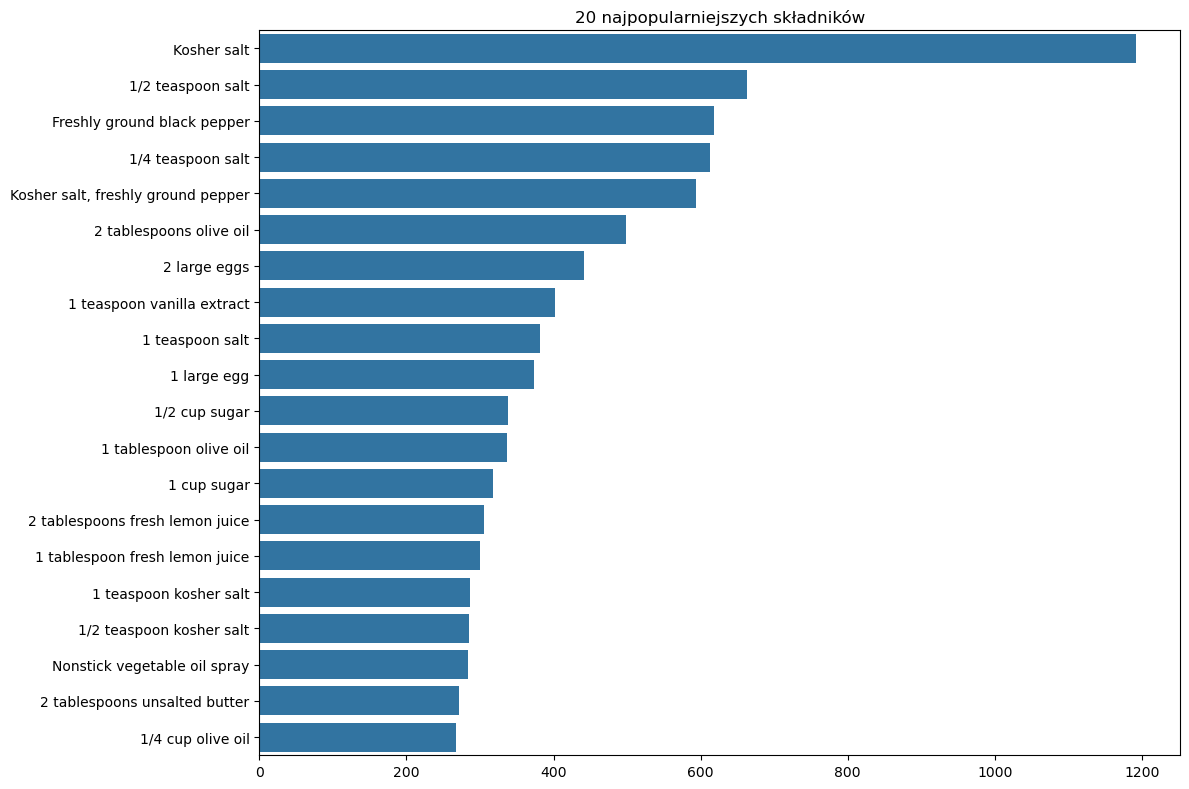


Liczba brakujących obrazów: 30


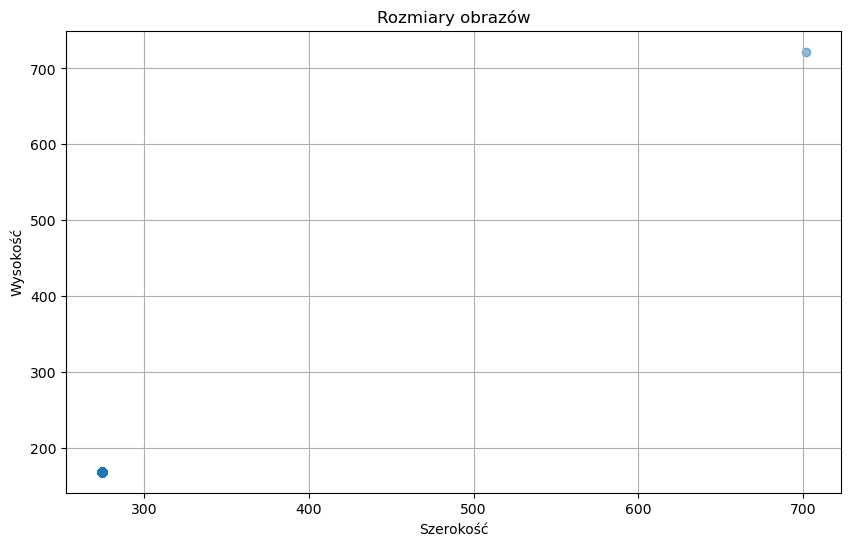

Średni rozmiar obrazu: 274.0 x 169.0
Minimalny rozmiar obrazu: 274 x 169
Maksymalny rozmiar obrazu: 702 x 722


In [5]:
# Ekstrakcja typu kuchni z nazw przepisów lub innych dostępnych informacji
# Załóżmy, że mamy kolumnę 'Cuisine' w danych
if 'Cuisine' in df.columns:
    # Liczność klas kuchni
    cuisine_counts = df['Cuisine'].value_counts()
    print("\nLiczność klas kuchni:")
    print(cuisine_counts)
    
    # Wizualizacja liczności klas kuchni
    plt.figure(figsize=(12, 6))
    sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values)
    plt.title('Liczność klas kuchni')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    # Jeśli nie ma kolumny 'Cuisine', musimy ją utworzyć na podstawie dostępnych danych
    # To może wymagać analizy nazw przepisów lub innych cech
    print("Kolumna 'Cuisine' nie istnieje. Konieczne jest utworzenie tej kolumny.")
    
# Analiza składników
# Konwersja stringów list na rzeczywiste listy pythonowe
df['Cleaned_Ingredients'] = df['Cleaned_Ingredients'].apply(ast.literal_eval)

# Zliczanie częstości występowania składników
all_ingredients = []
for ingredients_list in df['Cleaned_Ingredients']:
    all_ingredients.extend(ingredients_list)

ingredient_counts = Counter(all_ingredients)
most_common_ingredients = ingredient_counts.most_common(20)

print("\nNajpopularniejsze składniki:")
for ingredient, count in most_common_ingredients:
    print(f"{ingredient}: {count}")

# Wizualizacja najpopularniejszych składników
plt.figure(figsize=(12, 8))
ingredients, counts = zip(*most_common_ingredients)
sns.barplot(x=list(counts), y=list(ingredients))
plt.title('20 najpopularniejszych składników')
plt.tight_layout()
plt.show()

# Analiza obrazów
image_sizes = []
missing_images = 0

for image_name in df['Image_Name']:
    image_path = os.path.join(images_path, image_name + '.jpg')
    if os.path.exists(image_path):
        img = Image.open(image_path)
        image_sizes.append(img.size)
    else:
        missing_images += 1

print(f"\nLiczba brakujących obrazów: {missing_images}")

if image_sizes:
    # Analiza rozmiarów obrazów
    widths, heights = zip(*image_sizes)
    plt.figure(figsize=(10, 6))
    plt.scatter(widths, heights, alpha=0.5)
    plt.xlabel('Szerokość')
    plt.ylabel('Wysokość')
    plt.title('Rozmiary obrazów')
    plt.grid(True)
    plt.show()
    
    print(f"Średni rozmiar obrazu: {np.mean(widths):.1f} x {np.mean(heights):.1f}")
    print(f"Minimalny rozmiar obrazu: {min(widths)} x {min(heights)}")
    print(f"Maksymalny rozmiar obrazu: {max(widths)} x {max(heights)}")


In [7]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pobieranie stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Funkcja do przetwarzania składników
def preprocess_ingredients(ingredients_list):
    # Łączenie składników w jeden string
    ingredients_text = ' '.join(ingredients_list)
    # Usuwanie liczb, jednostek miary itp.
    ingredients_text = re.sub(r'\d+', '', ingredients_text)
    ingredients_text = re.sub(r'cup|tablespoon|teaspoon|pound|ounce|tbsp|tsp|oz|lb|g|ml|l', '', ingredients_text)
    # Usuwanie znaków interpunkcyjnych
    ingredients_text = re.sub(r'[^\w\s]', '', ingredients_text)
    # Konwersja na małe litery
    ingredients_text = ingredients_text.lower()
    # Usuwanie stopwords
    words = ingredients_text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Przetwarzanie składników
df['Processed_Ingredients'] = df['Cleaned_Ingredients'].apply(preprocess_ingredients)

# Metoda 1: TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_ingredients_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Ingredients'])

# Metoda 2: Tokenizacja i sekwencjonowanie dla embeddings
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['Processed_Ingredients'])
X_ingredients_seq = tokenizer.texts_to_sequences(df['Processed_Ingredients'])
X_ingredients_padded = pad_sequences(X_ingredients_seq, maxlen=100)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MAXIMUS_PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Funkcja do wczytywania i przetwarzania obrazów
def load_and_preprocess_image(image_name, target_size=(224, 224), preprocess_func=None):
    image_path = os.path.join(images_path, image_name + '.jpg')
    if os.path.exists(image_path):
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        if preprocess_func:
            img_array = preprocess_func(img_array)
        return img_array
    else:
        return None

# Generator danych do augmentacji
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Wczytywanie obrazów dla ResNet
X_images_resnet = []
for image_name in df['Image_Name']:
    img_array = load_and_preprocess_image(image_name, preprocess_func=resnet_preprocess)
    if img_array is not None:
        X_images_resnet.append(img_array)
X_images_resnet = np.array(X_images_resnet)

# Wczytywanie obrazów dla VGG
X_images_vgg = []
for image_name in df['Image_Name']:
    img_array = load_and_preprocess_image(image_name, preprocess_func=vgg_preprocess)
    if img_array is not None:
        X_images_vgg.append(img_array)
X_images_vgg = np.array(X_images_vgg)


MemoryError: Unable to allocate 7.55 GiB for an array with shape (13471, 224, 224, 3) and data type float32

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Kodowanie etykiet
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Cuisine'])

# Podział danych na zbiory treningowy i testowy
X_ingredients_train, X_ingredients_test, X_images_train, X_images_test, y_train, y_test = train_test_split(
    X_ingredients_padded, X_images_resnet, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Model MLP dla składników
def create_mlp_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Model dla TF-IDF
mlp_tfidf_model = create_mlp_model(X_ingredients_tfidf.shape[1], len(label_encoder.classes_))

# Trenowanie modelu
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_mlp_tfidf = mlp_tfidf_model.fit(
    X_ingredients_tfidf.toarray(), y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

# Model dla embeddings
def create_embedding_model(vocab_size, embedding_dim, input_length, num_classes):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=input_length),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Parametry modelu
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
input_length = X_ingredients_padded.shape[1]

# Tworzenie i trenowanie modelu
mlp_embedding_model = create_embedding_model(vocab_size, embedding_dim, input_length, len(label_encoder.classes_))
history_mlp_embedding = mlp_embedding_model.fit(
    X_ingredients_padded, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)


In [ ]:
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

# Model ResNet50
def create_resnet_model(num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Zamrożenie warstw bazowego modelu
    for layer in base_model.layers:
        layer.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Tworzenie i trenowanie modelu ResNet
resnet_model = create_resnet_model(len(label_encoder.classes_))
history_resnet = resnet_model.fit(
    X_images_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

# Model VGG16
def create_vgg_model(num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Zamrożenie warstw bazowego modelu
    for layer in base_model.layers:
        layer.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Tworzenie i trenowanie modelu VGG
vgg_model = create_vgg_model(len(label_encoder.classes_))
history_vgg = vgg_model.fit(
    X_images_vgg, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import concatenate

# Funkcja do tworzenia modelu multimodalnego
def create_multimodal_model(text_input_dim, image_input_shape, num_classes):
    # Gałąź tekstowa (MLP)
    text_input = Input(shape=(text_input_dim,))
    text_features = Dense(256, activation='relu')(text_input)
    text_features = Dropout(0.3)(text_features)
    text_features = Dense(128, activation='relu')(text_features)
    
    # Gałąź obrazowa (CNN)
    image_input = Input(shape=image_input_shape)
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    
    # Zamrożenie warstw bazowego modelu
    for layer in base_model.layers:
        layer.trainable = False
    
    image_features = GlobalAveragePooling2D()(base_model.output)
    image_features = Dense(256, activation='relu')(image_features)
    image_features = Dropout(0.3)(image_features)
    
    # Połączenie gałęzi
    combined = concatenate([text_features, image_features])
    
    # Wspólne warstwy
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    
    # Warstwa wyjściowa
    output = Dense(num_classes, activation='softmax')(x)
    
    # Tworzenie modelu
    model = Model(inputs=[text_input, image_input], outputs=output)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Tworzenie modelu multimodalnego
multimodal_model = create_multimodal_model(
    X_ingredients_tfidf.shape[1], 
    (224, 224, 3), 
    len(label_encoder.classes_)
)

# Trenowanie modelu
history_multimodal = multimodal_model.fit(
    [X_ingredients_train, X_images_train], y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping]
)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Ewaluacja modelu składników (MLP)
y_pred_mlp = mlp_tfidf_model.predict(X_ingredients_test.toarray())
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

print("\nWyniki modelu MLP (składniki):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp_classes):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_mlp_classes, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_classes, target_names=label_encoder.classes_))

# Ewaluacja modelu obrazów (ResNet)
y_pred_resnet = resnet_model.predict(X_images_test)
y_pred_resnet_classes = np.argmax(y_pred_resnet, axis=1)

print("\nWyniki modelu ResNet (obrazy):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_resnet_classes):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_resnet_classes, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_resnet_classes, target_names=label_encoder.classes_))

# Ewaluacja modelu obrazów (VGG)
y_pred_vgg = vgg_model.predict(X_images_test)
y_pred_vgg_classes = np.argmax(y_pred_vgg, axis=1)

print("\nWyniki modelu VGG (obrazy):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_vgg_classes):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_vgg_classes, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_vgg_classes, target_names=label_encoder.classes_))

# Ewaluacja modelu multimodalnego
y_pred_multimodal = multimodal_model.predict([X_ingredients_test.toarray(), X_images_test])
y_pred_multimodal_classes = np.argmax(y_pred_multimodal, axis=1)

print("\nWyniki modelu multimodalnego:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_multimodal_classes):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_multimodal_classes, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_multimodal_classes, target_names=label_encoder.classes_))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Funkcja do wizualizacji macierzy pomyłek
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Rzeczywista klasa')
    plt.xlabel('Przewidywana klasa')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Wizualizacja macierzy pomyłek dla wszystkich modeli
plot_confusion_matrix(y_test, y_pred_mlp_classes, label_encoder.classes_, 'Macierz pomyłek - Model MLP (składniki)')
plot_confusion_matrix(y_test, y_pred_resnet_classes, label_encoder.classes_, 'Macierz pomyłek - Model ResNet (obrazy)')
plot_confusion_matrix(y_test, y_pred_vgg_classes, label_encoder.classes_, 'Macierz pomyłek - Model VGG (obrazy)')
plot_confusion_matrix(y_test, y_pred_multimodal_classes, label_encoder.classes_, 'Macierz pomyłek - Model multimodalny')


In [ ]:
# Funkcja do wizualizacji historii treningu
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))
    
    # Wykres funkcji straty
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Walidacja')
    plt.title(f'{title} - Funkcja straty')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.legend()
    
    # Wykres dokładności
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Walidacja')
    plt.title(f'{title} - Dokładność')
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Wizualizacja historii treningu dla wszystkich modeli
plot_training_history(history_mlp_tfidf, 'Model MLP (składniki)')
plot_training_history(history_resnet, 'Model ResNet (obrazy)')
plot_training_history(history_vgg, 'Model VGG (obrazy)')
plot_training_history(history_multimodal, 'Model multimodalny')


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Implementacja Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Tworzenie modelu, który mapuje obraz wejściowy na aktywacje ostatniej warstwy konwolucyjnej
    # oraz na predykcje wyjściowe
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Obliczanie gradientu najwyższej przewidywanej klasy dla obrazu wejściowego
    # względem aktywacji ostatniej warstwy konwolucyjnej
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    # Gradient wyjściowego neuronu (najwyższej przewidywanej klasy)
    # względem mapy cech ostatniej warstwy konwolucyjnej
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    # Wektor, gdzie każdy element to średnia intensywność gradientu
    # dla określonego kanału mapy cech
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Mnożenie każdego kanału w mapie cech przez "jak ważny jest ten kanał"
    # względem najwyższej przewidywanej klasy, a następnie sumowanie wszystkich kanałów
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalizacja mapy cieplnej
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

# Funkcja do wizualizacji Grad-CAM
def display_gradcam(image_path, model, last_conv_layer_name, pred_index=None, alpha=0.4):
    # Wczytanie obrazu
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    
    # Generowanie mapy cieplnej Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index)
    
    # Wczytanie oryginalnego obrazu
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    
    # Zmiana rozmiaru mapy cieplnej do rozmiaru obrazu
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Konwersja mapy cieplnej na skalę kolorów
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Nałożenie mapy cieplnej na oryginalny obraz
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
    
    # Wyświetlenie obrazów
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Oryginalny obraz')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    plt.title('Mapa cieplna Grad-CAM')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title('Nałożona mapa cieplna')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Przykładowa wizualizacja Grad-CAM dla kilku obrazów testowych
sample_indices = np.random.choice(len(X_images_test), 5, replace=False)
for idx in sample_indices:
    image_path = os.path.join(images_path, df.iloc[idx]['Image_Name'] + '.jpg')
    pred_class = y_pred_resnet_classes[idx]
    true_class = y_test[idx]
    
    print(f"Obraz: {df.iloc[idx]['Title']}")
    print(f"Prawdziwa klasa: {label_encoder.classes_[true_class]}")
    print(f"Przewidywana klasa: {label_encoder.classes_[pred_class]}")
    
    # Wizualizacja Grad-CAM dla modelu ResNet
    display_gradcam(
        image_path, 
        resnet_model, 
        'conv5_block3_out',  # Ostatnia warstwa konwolucyjna w ResNet50
        pred_class
    )


In [ ]:
# Porównanie dokładności modeli
models = ['MLP (składniki)', 'ResNet (obrazy)', 'VGG (obrazy)', 'Multimodalny']
accuracies = [
    accuracy_score(y_test, y_pred_mlp_classes),
    accuracy_score(y_test, y_pred_resnet_classes),
    accuracy_score(y_test, y_pred_vgg_classes),
    accuracy_score(y_test, y_pred_multimodal_classes)
]
f1_scores = [
    f1_score(y_test, y_pred_mlp_classes, average='weighted'),
    f1_score(y_test, y_pred_resnet_classes, average='weighted'),
    f1_score(y_test, y_pred_vgg_classes, average='weighted'),
    f1_score(y_test, y_pred_multimodal_classes, average='weighted')
]

# Wizualizacja porównania modeli
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.title('Porównanie dokładności modeli')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(models, f1_scores, color=['blue', 'green', 'orange', 'red'])
plt.title('Porównanie F1-Score modeli')
plt.ylabel('F1-Score (weighted)')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Tabela porównawcza
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'F1-Score': f1_scores
})
print("\nTabela porównawcza modeli:")
print(comparison_df)
